# 1\. Distribuições

In [153]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
#from pandasql import sqldf
from plotly import express as ex

## 1.1 Normal

[5694.65 4228.65 4651.61 5598.75 4533.94 5145.53 5463.59 5074.56 5095.02
 5206.33 5780.   4398.19 5153.16 5306.52 5377.3  5052.64 4664.47 4531.25
 4215.22 5023.99]



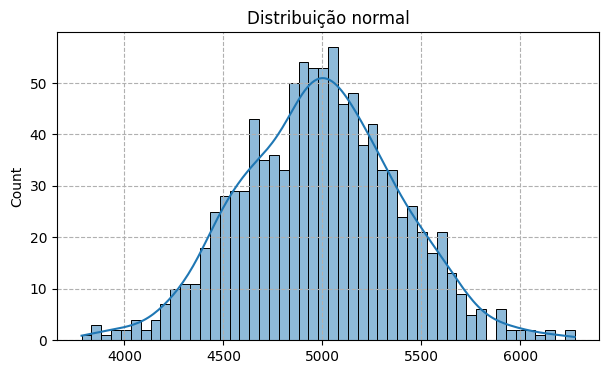

In [154]:
# DISTRIBUIÇÃO NORMAL
# nums aleatorios
normal = np.random.normal(loc=5000, scale=400, size=1000)
print(f'{normal[0:20].round(2)}\n')

# plot
fig, ax = plt.subplots(figsize=(7,4))
ax = sns.histplot(normal, bins=50, label='bins', kde=True)
ax.set_title('Distribuição normal')
ax.grid(True, ls='--');

## 1.2 Beta

Gera números aleatórios entre 0 e 1 a depender do alfa e beta da distribuição. Para mudar a faixa de valores diferentes de 0 e 1, multiplicar pelo número "médio".

```python
alfa = <alfa>
beta = <beta>
randoms = <numeros a gerar>
faixa = <"média" dos nºs a se gerar>
beta = np.random.beta(a=alfa, b=beta, size=randoms) * faixa
```

#### 1.2.1 Assimetria à esquerda

Quando `alfa > beta`, assimetria à esquerda:

[2559.31 2720.68 2807.6  1714.01 2191.99 3349.88 1094.65 3025.39 2937.53
 2710.92 2520.37 2761.03 3313.71 2427.58 1841.19 3086.32 2308.76 2979.01
 2030.78 2800.87]



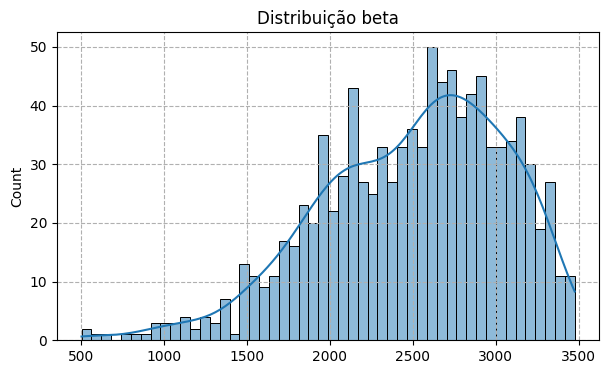

In [155]:
# DISTRIBUIÇÃO BETA
# nums aleatórios
beta = np.random.beta(a=5, b=2, size=1000)*3500     # a > b -> assimetrica esquerda  ;  a < b -> assimetrica direita
print(f'{beta[0:20].round(2)}\n')

# plot
fig, ax = plt.subplots(figsize=(7,4))
ax = sns.histplot(beta, bins=50, label='bins', kde=True)
ax.set_title('Distribuição beta')
ax.grid(True, ls='--');

#### 1.2.2 Assimetria à direita

Quando `alfa < beta`, assimetria à direita:

[ 652.84  205.44 1375.91 1189.62  467.    290.06  519.96 1469.43 1263.14
 2342.65 1631.22  211.51 1326.59 1758.09 1763.07  901.77 1538.67 1236.22
 1901.07 1469.02]



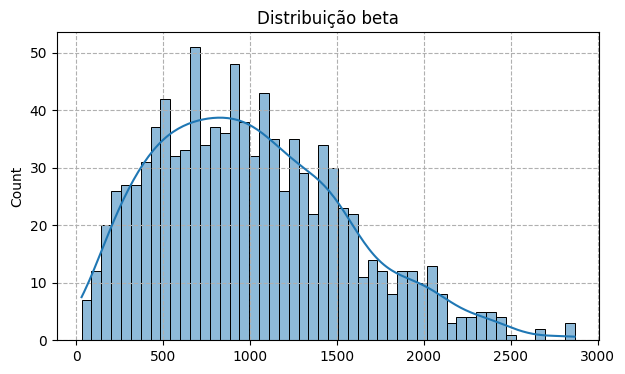

In [156]:
# DISTRIBUIÇÃO BETA
# nums aleatórios
beta = np.random.beta(a=2, b=5, size=1000)*3500     # a > b -> assimetrica esquerda  ;  a < b -> assimetrica direita
print(f'{beta[0:20].round(2)}\n')

# plot
fig, ax = plt.subplots(figsize=(7,4))
ax = sns.histplot(beta, bins=50, label='bins', kde=True)
ax.set_title('Distribuição beta')
ax.grid(True, ls='--');

# 2\. Gerando nºs aleatórios

### 2.1 renda

In [157]:
estados_F = pd.DataFrame(
{'estado':['DF', 'SP', 'RS', 'SC', 'RJ', 'PR', 'MS', 'ES', 'MT', 'GO', 'MG', 'TO', 'RO', 'RN', 
           'RR', 'SE', 'AP', 'PI', 'PB', 'PA', 'CE', 'AC', 'BA', 'PE','AM', 'AL', 'MA'],
 'renda':np.array([2913, 2148, 2087, 2018, 1971, 1846, 1839, 1723, 1674, 1619, 1529, 1379, 
          1365, 1267, 1242, 1187, 1177, 1110, 1096, 1061, 1050, 1038, 1010, 1010, 965, 935, 814])*2,
 'sexo':'F', 'A_renda':5, 'B_renda':2})

estados_M = pd.DataFrame(
{'estado':['DF', 'SP', 'RS', 'SC', 'RJ', 'PR', 'MS', 'ES', 'MT', 'GO', 'MG', 'TO', 'RO', 'RN', 
           'RR', 'SE', 'AP', 'PI', 'PB', 'PA', 'CE', 'AC', 'BA', 'PE','AM', 'AL', 'MA'],
 'renda':np.array([2913, 2148, 2087, 2018, 1971, 1846, 1839, 1723, 1674, 1619, 1529, 1379, 
          1365, 1267, 1242, 1187, 1177, 1110, 1096, 1061, 1050, 1038, 1010, 1010, 965, 935, 814])*2.3,
 'sexo':'M', 'A_renda':5, 'B_renda':2})

estados = pd.concat([estados_F, estados_M], axis=0)
#estados

In [158]:
faixas_F = pd.DataFrame({'sexo':'F', 
                         'faixa': ['10 ~ 19', '20 ~ 29', '30 ~ 39', '40 ~ 49', '50 ~ 59', '60 ~ 69', '70+'],
                         'ajuste':np.array([-500, -400, 0, 2000, 4000, 1500, 1000])})

faixas_M = pd.DataFrame({'sexo':'M', 
                         'faixa': ['10 ~ 19', '20 ~ 29', '30 ~ 39', '40 ~ 49', '50 ~ 59', '60 ~ 69', '70+'],
                         'ajuste':np.array([-500, -400, 0, 2200, 4100, 1550, 1200])*1.3})

faixas = pd.concat([faixas_F, faixas_M], axis=0)
#faixas

In [159]:
metricas = pd.merge(left=estados, right=faixas, on='sexo')
metricas.head()

,estado,renda,sexo,A_renda,B_renda,faixa,ajuste
0,DF,5826.0,F,5,2,10 ~ 19,-500.0
1,DF,5826.0,F,5,2,20 ~ 29,-400.0
2,DF,5826.0,F,5,2,30 ~ 39,0.0
3,DF,5826.0,F,5,2,40 ~ 49,2000.0
4,DF,5826.0,F,5,2,50 ~ 59,4000.0


In [160]:
aleatorios = {'estado':[], 'renda':[], 'sexo':[], 
              'A_renda':[], 'B_renda':[], 'faixa':[], 'ajuste':[], 'rnd':[]}

rep = 200

for col, values in metricas.iterrows():
  subset = (np.random.beta(a=values[3], b=values[4], size=rep) * values[1] + values[6]).tolist()
  for i in subset:
    aleatorios['rnd'].append(round(i, 2))
    aleatorios['estado'].append(values[0])
    aleatorios['renda'].append(values[1])
    aleatorios['sexo'].append(values[2])
    aleatorios['A_renda'].append(values[3])
    aleatorios['B_renda'].append(values[4])
    aleatorios['faixa'].append(values[5])
    aleatorios['ajuste'].append(values[6])

aleatorios = pd.DataFrame(aleatorios)
aleatorios.shape

(75600, 8)

In [161]:
aleatorios.head()

,estado,renda,sexo,A_renda,B_renda,faixa,ajuste,rnd
0,DF,5826.0,F,5,2,10 ~ 19,-500.0,2551.61
1,DF,5826.0,F,5,2,10 ~ 19,-500.0,4694.82
2,DF,5826.0,F,5,2,10 ~ 19,-500.0,4959.23
3,DF,5826.0,F,5,2,10 ~ 19,-500.0,2762.35
4,DF,5826.0,F,5,2,10 ~ 19,-500.0,2993.96


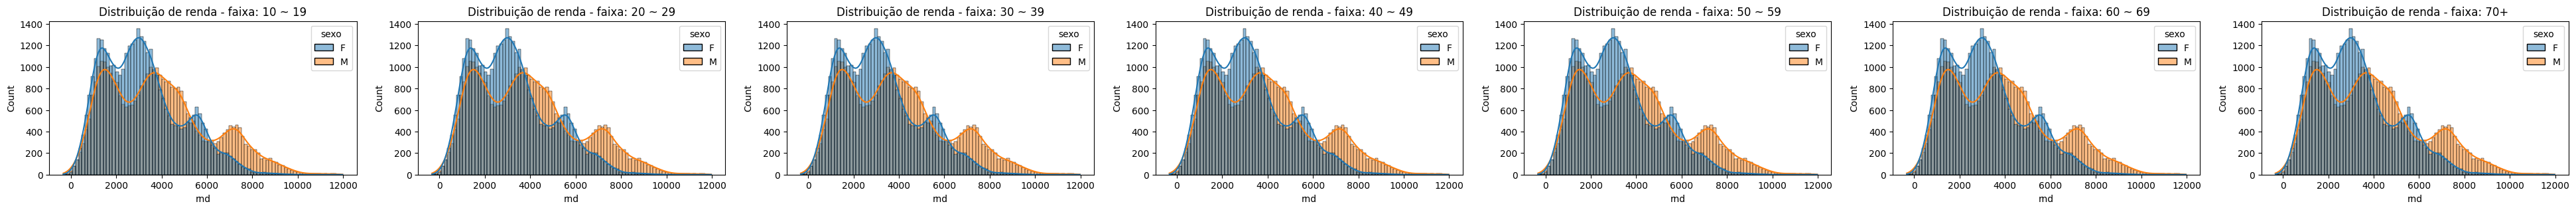

In [162]:
faixas_etarias = aleatorios['faixa'].unique()

fig, ax = plt.subplots(1, len(faixas_etarias), figsize=(7*len(faixas_etarias), 3))
for i in range(0, len(faixas_etarias)):
  ax[i] = sns.histplot(data=aleatorios[['estado', 'sexo', 'rnd']], x='rnd', hue='sexo', kde=True, ax=ax[i])
  ax[i].set_title(f'Distribuição de renda - faixa: {faixas_etarias[i]}');

In [163]:
aleatorios.to_csv('aleatorios.csv', sep=';', encoding='utf-8', index=False)

### 2.2 filhos

In [164]:
filhos_F = pd.DataFrame(
{'estado':['DF', 'SP', 'RS', 'SC', 'RJ', 'PR', 'MS', 'ES', 'MT', 'GO', 'MG', 'TO', 'RO', 'RN', 
           'RR', 'SE', 'AP', 'PI', 'PB', 'PA', 'CE', 'AC', 'BA', 'PE','AM', 'AL', 'MA'],
 'renda':np.array([0.944, 0.955, 0.965, 1.01, 1.01, 1.038, 1.05, 1.061, 1.096, 
                   1.11, 1.177, 1.187, 1.242, 1.267, 1.365, 1.379, 1.529, 1.619, 
                   1.674, 1.723, 1.839, 1.846, 1.971, 2.018, 2.087, 2.148, 2.913])*2,
 'sexo':'F', 'A_renda':2, 'B_renda':5})

filhos_M = pd.DataFrame(
{'estado':['DF', 'SP', 'RS', 'SC', 'RJ', 'PR', 'MS', 'ES', 'MT', 'GO', 'MG', 'TO', 'RO', 'RN', 
           'RR', 'SE', 'AP', 'PI', 'PB', 'PA', 'CE', 'AC', 'BA', 'PE','AM', 'AL', 'MA'],
 'renda':np.array([0.944, 0.955, 0.965, 1.01, 1.01, 1.038, 1.05, 1.061, 1.096, 
                   1.11, 1.177, 1.187, 1.242, 1.267, 1.365, 1.379, 1.529, 1.619, 
                   1.674, 1.723, 1.839, 1.846, 1.971, 2.018, 2.087, 2.148, 2.913])*2.3,
 'sexo':'M', 'A_renda':2, 'B_renda':5})

filhos = pd.concat([filhos_F, filhos_M], axis=0)
#filhos

In [165]:
faixas_F = pd.DataFrame({'sexo':'F', 
                         'faixa': ['10 ~ 19', '20 ~ 29', '30 ~ 39', '40 ~ 49', '50 ~ 59', '60 ~ 69', '70+'],
                         'ajuste':np.array([-500, -400, 0, 2000, 4000, 1500, 1000])/1000})

faixas_M = pd.DataFrame({'sexo':'M', 
                         'faixa': ['10 ~ 19', '20 ~ 29', '30 ~ 39', '40 ~ 49', '50 ~ 59', '60 ~ 69', '70+'],
                         'ajuste':(np.array([-500, -400, 0, 2200, 4100, 1550, 1200])/1000)*1.3})

faixas_filhos = pd.concat([faixas_F, faixas_M], axis=0)
#faixas_filhos

In [166]:
metricas_filhos = pd.merge(left=filhos, right=faixas_filhos, on='sexo')
metricas_filhos.head()

,estado,renda,sexo,A_renda,B_renda,faixa,ajuste
0,DF,1.888,F,2,5,10 ~ 19,-0.5
1,DF,1.888,F,2,5,20 ~ 29,-0.4
2,DF,1.888,F,2,5,30 ~ 39,0.0
3,DF,1.888,F,2,5,40 ~ 49,2.0
4,DF,1.888,F,2,5,50 ~ 59,4.0


In [167]:
aleatorios_filhos = {'estado':[], 'renda':[], 'sexo':[], 'A_renda':[], 
                     'B_renda':[], 'faixa':[], 'ajuste':[], 'rnd':[]}

rep = 200

for col, values in metricas_filhos.iterrows():
  subset = (np.random.beta(a=values[3], b=values[4], size=rep) * values[1] + values[6]).tolist()
  for i in subset:
    aleatorios_filhos['rnd'].append(round(i, 2))
    aleatorios_filhos['estado'].append(values[0])
    aleatorios_filhos['renda'].append(values[1])
    aleatorios_filhos['sexo'].append(values[2])
    aleatorios_filhos['A_renda'].append(values[3])
    aleatorios_filhos['B_renda'].append(values[4])
    aleatorios_filhos['faixa'].append(values[5])
    aleatorios_filhos['ajuste'].append(values[6])

aleatorios_filhos = pd.DataFrame(aleatorios_filhos)
aleatorios_filhos.shape

(75600, 8)

In [168]:
aleatorios_filhos.head()

,estado,renda,sexo,A_renda,B_renda,faixa,ajuste,rnd
0,DF,1.888,F,2,5,10 ~ 19,-0.5,-0.10
1,DF,1.888,F,2,5,10 ~ 19,-0.5,-0.29
2,DF,1.888,F,2,5,10 ~ 19,-0.5,0.06
3,DF,1.888,F,2,5,10 ~ 19,-0.5,-0.08
4,DF,1.888,F,2,5,10 ~ 19,-0.5,-0.12


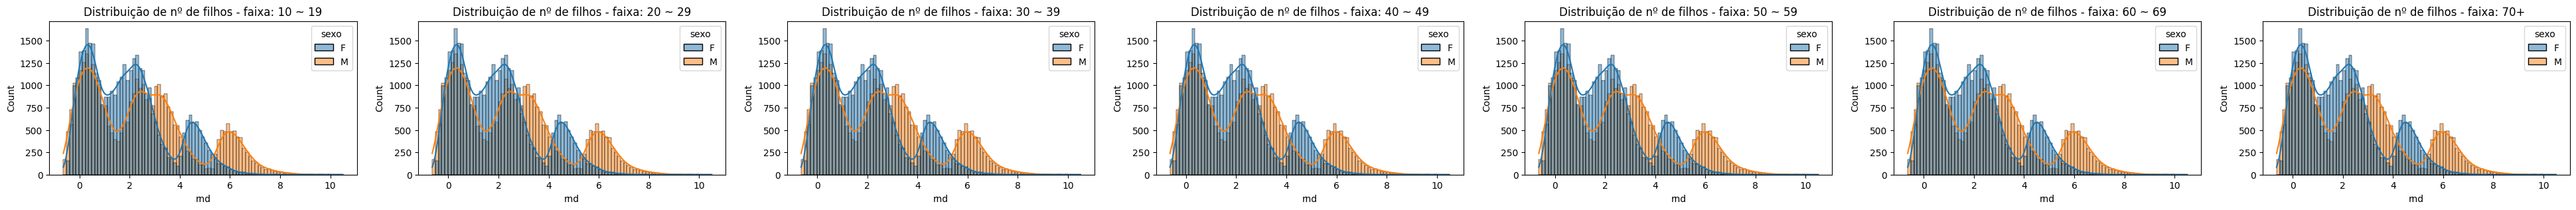

In [169]:
faixas_etarias = aleatorios_filhos['faixa'].unique()

fig, ax = plt.subplots(1, len(faixas_etarias), figsize=(7*len(faixas_etarias), 3))
for i in range(0, len(faixas_etarias)):
  ax[i] = sns.histplot(data=aleatorios_filhos[['estado', 'sexo', 'rnd']], x='rnd', hue='sexo', kde=True, ax=ax[i])
  ax[i].set_title(f'Distribuição de nº de filhos - faixa: {faixas_etarias[i]}');

In [171]:
aleatorios_filhos.to_csv('aleatorios_filhos.csv', sep=';', encoding='utf-8', index=False)